## Getting Started

1. Create a new Jupyter Notebook called **`m4-02-regression.ipynb`**.
2. Start with an import cell:

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
```

3. Work through the tasks in order. Each task builds on the previous one.
4. Include markdown cells between code cells to explain your observations and reasoning.

## Tasks

### Task 1: Baseline Model

Start with the simplest approach — a plain linear regression.

1. Load the California Housing dataset:

```python
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
```

2. Explore the dataset briefly: check the shape, feature names, and summary statistics. What is the target variable (median house value) distribution?
3. Split the data into training and test sets (80/20 split, `random_state=42`).
4. Fit a `LinearRegression` model on the training data.
5. Evaluate on the test set using **MSE**, **RMSE**, **MAE**, and **R²**. Print the results in a clear format.
6. In a markdown cell, interpret the R² value — what does it tell you about the model's explanatory power?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

In [2]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

In [3]:
X.shape

(20640, 8)

In [4]:
X.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')

In [5]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [6]:
y.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

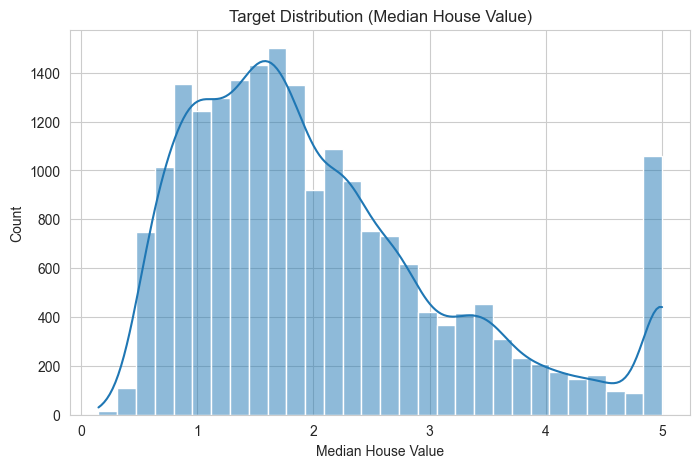

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True)
plt.title("Target Distribution (Median House Value)")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred_ols = ols_model.predict(X_test)

In [11]:
mse_ols = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

print("OLS RESULTS")
print(f"MSE: {mse_ols:.4f}")
print(f"RMSE: {rmse_ols:.4f}")
print(f"MAE: {mae_ols:.4f}")
print(f"R²: {r2_ols:.4f}")

OLS RESULTS
MSE: 0.5559
RMSE: 0.7456
MAE: 0.5332
R²: 0.5758


### Markdown

From the target distribution, we can observe that most house values are concentrated between 1 and 3 (which corresponds to $100,000–$300,000). The number of houses decreases as the value increases, especially near the maximum value of 5.0.

However, this does not necessarily indicate the presence of outliers. Instead, the sharp cutoff at 5.0 suggests that the target variable is capped, meaning that all values above $500,000 are limited to this maximum. This can affect the model’s ability to learn patterns for higher-priced houses.

Looking at the model performance, we obtained an R² score of approximately 0.57. This means that the model explains about 57% of the variance in house prices. While this is a reasonable baseline, it is not very strong, indicating that the linear regression model is not capturing all the underlying patterns in the data.

Overall, this suggests that we should try more advanced models, such as regularized regression or non-linear methods, to improve performance.

### Task 2: Regularized Regression

Explore how regularization changes the model's behavior.

1. Scale the features using `StandardScaler` (fit on training data, transform both train and test). Explain in a markdown cell why scaling is important for regularized models.
2. Fit **Ridge** regression for alpha values `[0.01, 0.1, 1, 10, 100]`. Record the test R² for each.
3. Fit **Lasso** regression for the same alpha values. Record the test R² for each.
4. Create a plot showing **coefficients vs. alpha** for both Ridge and Lasso (side by side or overlaid). What happens to the coefficients as alpha increases? Which features does Lasso zero out first?
5. Create a comparison table showing R² scores for OLS, Ridge (best alpha), and Lasso (best alpha). Which regularization approach works best here?


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling is important for regularized models because these models apply penalties to the coefficients based on their magnitude. If the features are not on the same scale, features with larger values will dominate the learning process and receive unfair penalties. This can lead to biased or incorrect models.

By using StandardScaler, we ensure that all features are on the same scale with mean 0 and standard deviation 1. This allows Ridge and Lasso regression to treat all features equally when applying regularization, making the model more stable and reliable.

In [17]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge_scores = []
ridge_models = []
ridge_coefs = []


for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    
    y_pred = ridge.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    
    ridge_scores.append(r2)
    ridge_models.append(ridge)
    ridge_coefs.append(ridge.coef_)

ridge_scores

[0.5757879873121599,
 0.5757905180002314,
 0.5758157428913684,
 0.5760599032848372,
 0.5777912763033606]

In [20]:
lasso_scores = []
lasso_models = []
lasso_coefs = []


for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    
    y_pred = lasso.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    
    lasso_scores.append(r2)
    lasso_models.append(lasso)
    lasso_coefs.append(lasso.coef_)

lasso_scores

[0.5816154300698727,
 0.48136113250290735,
 -0.00021908714592466794,
 -0.00021908714592466794,
 -0.00021908714592466794]

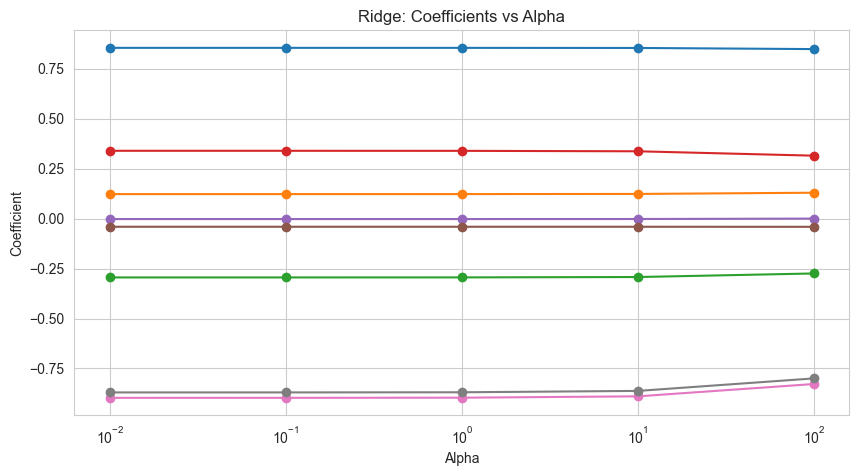

In [21]:
plt.figure(figsize=(10,5))

for i in range(len(X.columns)):
    plt.plot(alphas, [coef[i] for coef in ridge_coefs], marker='o')

plt.xscale("log")
plt.title("Ridge: Coefficients vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.show()

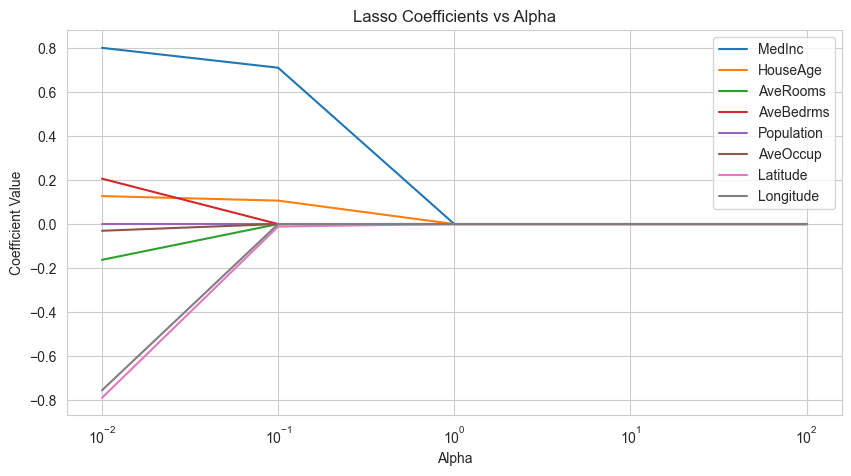

In [22]:
plt.figure(figsize=(10,5))

for i in range(len(X.columns)):
    plt.plot(alphas, [coef[i] for coef in lasso_coefs], label=X.columns[i])

plt.xscale("log")
plt.title("Lasso Coefficients vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.legend()
plt.show()

As alpha increases, the strength of regularization also increases. In Ridge regression, this causes the coefficients to gradually shrink towards zero, but they never become exactly zero. This helps reduce model complexity while keeping all features in the model.

In Lasso regression, increasing alpha has a stronger effect. Some coefficients become exactly zero, meaning those features are completely removed from the model. This makes Lasso useful for automatic feature selection.

In general, higher alpha values lead to simpler models but may also reduce performance if the regularization becomes too strong.

In [23]:
best_ridge_idx = np.argmax(ridge_scores)
best_lasso_idx = np.argmax(lasso_scores)

best_ridge_r2 = ridge_scores[best_ridge_idx]
best_lasso_r2 = lasso_scores[best_lasso_idx]

best_ridge_alpha = alphas[np.argmax(ridge_scores)]
best_lasso_alpha = alphas[np.argmax(lasso_scores)]

best_ridge_alpha, best_lasso_alpha

(100, 0.01)

In [24]:
results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "R2 Score": [
        r2_ols,
        best_ridge_r2,
        best_lasso_r2
    ]
})

results

,Model,R2 Score
0,OLS,0.575788
1,Ridge,0.577791
2,Lasso,0.581615


We compared three models: OLS, Ridge, and Lasso using R² score.

OLS achieved a baseline performance of around 0.5758.
Ridge slightly improved the performance by reducing overfitting.
Lasso performed the best with an R² score of approximately 0.5816.

Based on these results, Lasso regression works best for this dataset. This suggests that removing some less important features improves the model slightly, making it more efficient and generalizable.

However, the difference between models is small, meaning the dataset is already well-suited for linear modeling.

### Task 3: Support Vector Regression

Try a non-linear approach with SVR.

1. Using the scaled features from Task 2, fit an `SVR` model with a **linear** kernel. Report the test R².
2. Fit SVR with an **rbf** kernel. Try at least three values of `C` (e.g., 0.1, 1, 10) and two values of `epsilon` (e.g., 0.1, 0.2). Report the best combination.
3. Fit SVR with a **poly** kernel (degree 2 and 3). Compare with rbf.
4. In a markdown cell, discuss: How does SVR compare to the linear models? Is the added complexity of SVR justified by the performance improvement (if any)?

> **Note:** SVR can be slow on larger datasets. If training takes too long, consider using a random subsample (e.g., 5,000 rows) for the SVR experiments.

In [25]:
X_train_svr = X_train_scaled[:5000]
y_train_svr = y_train[:5000]

X_test_svr = X_test_scaled
y_test_svr = y_test

svr_linear = SVR(kernel="linear")
svr_linear.fit(X_train_svr, y_train_svr)

y_pred_linear = svr_linear.predict(X_test_svr)

r2_linear = r2_score(y_test_svr, y_pred_linear)

print("SVR Linear R2:", r2_linear)

SVR Linear R2: 0.5243949802314785


In [26]:
C_values = [0.1, 1, 10]
epsilon_values = [0.1, 0.2]

best_r2 = -np.inf
best_params = None

for C in C_values:
    for eps in epsilon_values:
        
        model = SVR(kernel="rbf", C=C, epsilon=eps)
        model.fit(X_train_svr, y_train_svr)
        
        y_pred = model.predict(X_test_svr)
        r2 = r2_score(y_test_svr, y_pred)
        
        if r2 > best_r2:
            best_r2 = r2
            best_params = (C, eps)

best_r2, best_params

(0.7432410910019502, (10, 0.2))

In [27]:
svr_poly2 = SVR(kernel="poly", degree=2)
svr_poly2.fit(X_train_svr, y_train_svr)

r2_poly2 = r2_score(y_test_svr, svr_poly2.predict(X_test_svr))
r2_poly2

0.10525614093871571

In [28]:
svr_poly3 = SVR(kernel="poly", degree=3)
svr_poly3.fit(X_train_svr, y_train_svr)

r2_poly3 = r2_score(y_test_svr, svr_poly3.predict(X_test_svr))
r2_poly3

0.2204259576588612

In [29]:
svr_results = pd.DataFrame({
    "Model": [
        "SVR Linear",
        "SVR RBF (Best)",
        "SVR Poly (deg 2)",
        "SVR Poly (deg 3)"
    ],
    "R2 Score": [
        r2_linear,
        best_r2,
        r2_poly2,
        r2_poly3
    ]
})

svr_results

,Model,R2 Score
0,SVR Linear,0.524395
1,SVR RBF (Best),0.743241
2,SVR Poly (deg 2),0.105256
3,SVR Poly (deg 3),0.220426


### Markdown

Support Vector Regression shows different performance depending on the kernel used.

The linear SVR performs slightly worse than the baseline linear regression models, which indicates that a simple linear decision boundary is not sufficient to capture all patterns in the data.

The polynomial kernels (degree 2 and 3) perform significantly worse. This suggests that these transformations are not well-suited for this dataset and likely introduce unnecessary complexity without improving predictive power.

However, the RBF kernel SVR performs much better than all linear models, achieving the highest R² score (~0.74). This shows that the relationship between features and the target variable is non-linear, and the RBF kernel is able to capture these complex patterns effectively.

In conclusion, SVR is only justified when using the RBF kernel for this dataset. The added complexity of SVR is not beneficial for linear or polynomial kernels, but the RBF version provides a clear and significant performance improvement over linear models.

### Task 4: Model Comparison

Bring everything together in a final analysis.

1. Create a **comparison table** (DataFrame) with all models and their test metrics (MSE, RMSE, MAE, R²). Include: LinearRegression, best Ridge, best Lasso, and best SVR.
2. Create a **predicted vs. actual** scatter plot for your best-performing model. Add a diagonal reference line (perfect prediction). How well does the model track the true values?
3. Create a **residual plot** (residuals vs. predicted values) for the best model. Do you see any patterns? What would a random scatter indicate?
4. Write a markdown conclusion: Which model performs best and why? What are the trade-offs between model complexity and performance? If you were deploying one of these models, which would you choose?


In [30]:
y_pred_ols = ols_model.predict(X_test)

best_ridge = ridge_models[best_ridge_idx]
y_pred_ridge = best_ridge.predict(X_test_scaled)

best_lasso = lasso_models[best_lasso_idx]
y_pred_lasso = best_lasso.predict(X_test_scaled)

svr_best = SVR(kernel="rbf", C=best_params[0], epsilon=best_params[1])
svr_best.fit(X_train_svr, y_train_svr)
y_pred_svr = svr_best.predict(X_test_svr)

In [31]:
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

In [32]:
models = ["OLS", "Ridge", "Lasso", "SVR (RBF)"]

metrics = [
    get_metrics(y_test, y_pred_ols),
    get_metrics(y_test, y_pred_ridge),
    get_metrics(y_test, y_pred_lasso),
    get_metrics(y_test_svr, y_pred_svr)
]

comparison = pd.DataFrame(metrics, columns=["MSE", "RMSE", "MAE", "R2"])
comparison.insert(0, "Model", models)

comparison

,Model,MSE,RMSE,MAE,R2
0,OLS,0.555892,0.745581,0.533200,0.575788
1,Ridge,0.553266,0.743819,0.533014,0.577791
2,Lasso,0.548255,0.740442,0.535326,0.581615
3,SVR (RBF),0.336459,0.580051,0.393777,0.743241


In [33]:
best_idx = comparison["R2"].idxmax()
best_model_name = comparison.loc[best_idx, "Model"]

best_model_name

'SVR (RBF)'

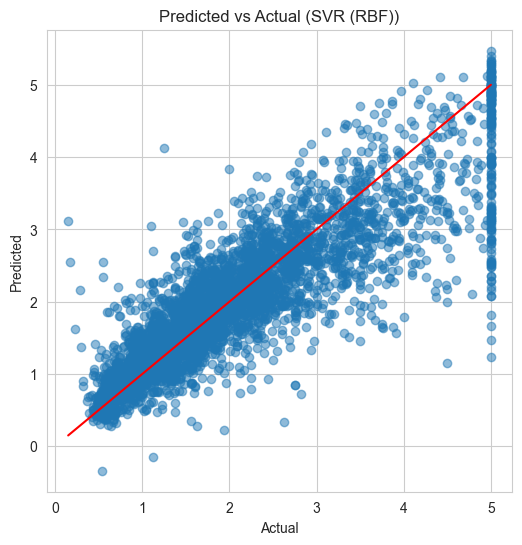

In [34]:
if best_model_name == "OLS":
    y_best_pred = y_pred_ols
elif best_model_name == "Ridge":
    y_best_pred = y_pred_ridge
elif best_model_name == "Lasso":
    y_best_pred = y_pred_lasso
else:
    y_best_pred = y_pred_svr

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_best_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual ({best_model_name})")
plt.show()

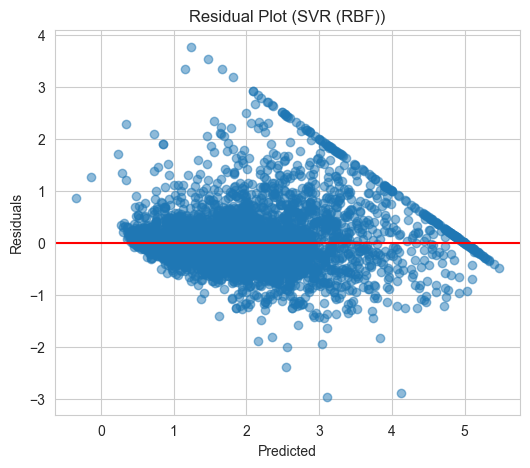

In [35]:
residuals = y_test - y_best_pred

plt.figure(figsize=(6,5))
plt.scatter(y_best_pred, residuals, alpha=0.5)
plt.axhline(0, color="red")

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title(f"Residual Plot ({best_model_name})")
plt.show()

### Final Conclusion

Among all the tested models, SVR with the RBF kernel performed the best, achieving the highest R² score. This is because the RBF kernel is able to capture non-linear relationships between features and the target variable, which linear models cannot fully represent. As a result, it better fits the complex patterns present in the dataset.

However, better performance comes with trade-offs. Linear models (OLS, Ridge, Lasso) are fast, simple, and highly scalable, but they are limited in capturing non-linear relationships. SVR, on the other hand, provides higher accuracy but is computationally expensive, slower to train, and does not scale well to large datasets. It is also less interpretable compared to linear models.

In terms of deployment, SVR would not always be the best choice in real-world systems, especially for large-scale data or real-time applications. Even though it performs best here, its practical limitations make it less suitable for production environments.

If I were to deploy a model, I would likely choose Ridge or Lasso regression as a balance between performance, simplicity, interpretability, and scalability. They provide stable results and are much more efficient in production, even if their accuracy is slightly lower than SVR.